# Group Assignment #4
### Author: Gema Martinez

## Who’s Most at Risk? Social Demographics and Traffic Collisions in the City of Los Angeles
This notebook examines the Spatial Autocorrelation Analysis of fatalities (bike and pedestrians) in the City of Los Angeles from 2015-2019 using UC Berkeley's Transportation Injury Mapping System (TIMS) data.

## Data Sources & Geographic Information
2019 Census Tracts from IPUMS NHGIS (At the time, we could not download the TIGER/Shapefile due to federal government actions).

2015 - 2019 UC Berkeley - TIMS

In [1]:
# to read and wrangle data
import pandas as pd

# to create spatial data
import geopandas as gpd

# for basemaps
import contextily as ctx

# For spatial statistics
import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation

import libpysal as lps

# Graphics
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# importing census tracts
la_tracts = gpd.read_file('Data/cityLA.zip')

In [3]:
# our zip file does not include total population needed for future analysis 
# upload acs 2015-2019 data 
income = pd.read_csv('Data/R13808337_SL140.csv')

In [4]:
#converting FIPS, STATE, and COUNTY from integer to string & reintegrate leading zero
income = pd.read_csv(
    'Data/R13808337_SL140.csv',
    dtype=
    {
        'Geo_FIPS':str,
        'Geo_STATE':str,
        'Geo_COUNTY': str
    }
)

In [5]:
#refining data to keep only necessary columns
columns_to_keep = ['Geo_FIPS', 
                   'Geo_STATE', 
                   'Geo_COUNTY',
                   'SE_A14006_001']

income = income[columns_to_keep]

In [6]:
#remnaing columns
income.columns = ['FIPS',
                'State',
                'County',
                'Median Income']

In [7]:
#importing total population csv from ACS 2015-2019 to include in median income dataframe
total_population = pd.read_csv('Data/Total Population.csv')

In [8]:
#converting FIPS, STATE, and COUNTY from integer to string & reintegrate leading zero
total_population = pd.read_csv(
    'Data/Total Population.csv',
    dtype=
    {
        'Geo_FIPS':str,
        'Geo_STATE':str,
        'Geo_COUNTY': str,
        'SE_A00001_001': str
    }
)

In [9]:
#cleaning total pop data
columns_to_keep_pop = ['Geo_FIPS', 
                   'Geo_STATE', 
                   'Geo_COUNTY',
                   'SE_A00001_001']

total_population = total_population[columns_to_keep_pop]

In [10]:
#renaming columns
total_population.columns = ['FIPS',
                'State',
                'County',
                'Total Population']

In [11]:
#checking dataframe
total_population.head(2)

,FIPS,State,County,Total Population
0,06037101110,06,037,4283
1,06037101122,06,037,3405


In [12]:
#merging income and total population
income_pop = income.merge(total_population, on="FIPS")

In [13]:
#checking that both dataframes merged together
income_pop.head(2)

,FIPS,State_x,County_x,Median Income,State_y,County_y,Total Population
0,06037101110,06,037,63534.0,06,037,4283
1,06037101122,06,037,90389.0,06,037,3405


In [14]:
# creating new FIPS column to prepare census tracts dataframe for mergining
la_tracts['FIPS'] = '06' + '037' + la_tracts['TRACTCE']

In [15]:
# merging census tracts and total population 
la_city = la_tracts.merge(total_population, on="FIPS")

In [16]:
#checking that data merged
la_city.head(2)

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,INTPTLAT,INTPTLON,Shape_Leng,Shape_Le_1,Shape_Area,geometry,FIPS,State,County,Total Population
0,G0600370101110,06,037,101110,06037101110,1011.10,Census Tract 1011.10,G5020,S,1142401.0,...,+34.2594737,-118.2929869,4585.520052,4585.520052,1.142400e+06,"POLYGON ((-2019033.589 -124429.155, -2018948.5...",06037101110,06,037,4283
1,G0600370101122,06,037,101122,06037101122,1011.22,Census Tract 1011.22,G5020,S,2644045.0,...,+34.2677213,-118.2901465,9652.233049,9652.233049,2.644046e+06,"POLYGON ((-2017297.948 -125225.326, -2017305.0...",06037101122,06,037,3405


In [17]:
#cleaning the data to only include necessary columns 
columns_to_keep_la = ['FIPS', 
                   'Total Population', 
                   'geometry']

la_city = la_city[columns_to_keep_la]

In [18]:
# identifying total population row to delete; there is no total population column 
la_city.tail()

,FIPS,Total Population,geometry
1163,06037980026,26,"POLYGON ((-2017734.652 -121289.969, -2017604.1..."
1164,06037980028,0,"POLYGON ((-2037371.498 -155528.944, -2037368.6..."
1165,06037980030,0,"POLYGON ((-2039470.503 -159401.276, -2039585.4..."
1166,06037980031,1175,"MULTIPOLYGON (((-2027306.945 -179844.798, -202..."
1167,06037980033,16,"MULTIPOLYGON (((-2027800.331 -180973.621, -202..."


In [19]:
# modifuing total population to numerical values to fix sorting issue (the column was not sorting)
la_city['Total Population'] = pd.to_numeric(la_city['Total Population'], errors='coerce')
la_city.sort_values(by='Total Population', ascending=True).head(20)

,FIPS,Total Population,geometry
1165,06037980030,0,"POLYGON ((-2039470.503 -159401.276, -2039585.4..."
1164,06037980028,0,"POLYGON ((-2037371.498 -155528.944, -2037368.6..."
1008,06037320000,0,"MULTIPOLYGON (((-2026987.276 -137679.181, -202..."
1149,06037980002,0,"MULTIPOLYGON (((-2025190.604 -177036.987, -202..."
1158,06037980020,0,"POLYGON ((-2019136.183 -127669.077, -2019102.7..."
1160,06037980022,0,"POLYGON ((-2034697.534 -114703.299, -2034687.1..."
1161,06037980023,0,"POLYGON ((-2047272.84 -120824.771, -2047312.73..."
1154,06037980013,0,"MULTIPOLYGON (((-2034925.473 -159035.208, -203..."
1150,06037980005,0,"POLYGON ((-2030557.304 -168200.728, -2030641.3..."
1148,06037980001,0,"MULTIPOLYGON (((-2026441.139 -130545.925, -202..."


In [20]:
# deleting entries where the total population is less than 100
la_city = la_city[la_city['Total Population']>100]

In [21]:
# upload crash data 
# use pandas since we do not have geometry data 
collisions = pd.read_csv('Data/All Collisions.csv')

In [24]:
collisions.head(10)

,CASE_ID,ACCIDENT_YEAR,PROC_DATE,JURIS,COLLISION_DATE,COLLISION_TIME,OFFICER_ID,REPORTING_DISTRICT,DAY_OF_WEEK,CHP_SHIFT,...,COUNT_MC_KILLED,COUNT_MC_INJURED,PRIMARY_RAMP,SECONDARY_RAMP,LATITUDE,LONGITUDE,COUNTY,CITY,POINT_X,POINT_Y
0,9381563,2022,2022-02-22,1942,2022-01-03,152,42011,0394,1,5,...,0,0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.325279,34.003670
1,9396835,2022,2022-02-10,1942,2022-01-12,1840,37724,1806,3,5,...,0,0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.256432,33.953281
2,9400731,2022,2022-02-11,1942,2022-01-24,1620,40289,1126,1,5,...,0,0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.202553,34.120640
3,9433384,2022,2022-08-15,1942,2022-07-15,2100,41516,0765,5,5,...,0,0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.344223,34.050346
4,9434092,2022,2022-04-12,1942,2022-03-18,2215,35936,1265,5,5,...,0,0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.291771,33.960026
5,9437651,2022,2022-05-16,1942,2022-04-25,1350,42758,1249,1,5,...,0,0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.283806,33.974659
6,91942226,2022,2022-12-14,9590,2022-11-26,1242,022357,NaN,6,1,...,0,0,-,-,34.042252,-118.217758,LOS ANGELES,LOS ANGELES,-118.217766,34.042252
7,91964717,2022,2023-01-10,9540,2022-12-31,945,021349,NaN,6,1,...,0,0,-,-,34.319500,-118.494293,LOS ANGELES,LOS ANGELES,-118.494179,34.319611
8,91965419,2022,2023-01-11,9590,2022-11-27,2145,022701,NaN,7,2,...,0,0,-,-,34.006390,-118.281357,LOS ANGELES,LOS ANGELES,-118.281120,34.006390
9,91994162,2022,2023-02-14,9590,2022-10-29,1908,022683,NaN,6,2,...,0,0,-,-,34.006260,-118.280983,LOS ANGELES,LOS ANGELES,-118.280991,34.006260


In [25]:
# convert data to geodataframe to plot 
collisions = gpd.GeoDataFrame(collisions, 
                         crs ='EPSG:4326', 
                         geometry=gpd.points_from_xy(collisions.POINT_X, collisions.POINT_Y))

In [29]:
# calculating the bounds for crash data 
# purpose - we want to zoom into the crash layer and NOT census tracts 
minx, miny, maxx, maxy = collisions.geometry.total_bounds
print(minx)
print(maxx)
print(miny)
print(maxy)

-13226441.707084872
-13118211.970834948
3989996.0374453706
4168860.4746364797


In [30]:
#joining census tracrts and pedestrian collisions
collisions = collisions.to_crs(epsg=3857)
la_city = la_city.to_crs(epsg=3857)
join = gpd.sjoin(la_city, collisions, how='left')

In [31]:
join.head(5)

,FIPS,Total Population,geometry,index_right,CASE_ID,ACCIDENT_YEAR,PROC_DATE,JURIS,COLLISION_DATE,COLLISION_TIME,...,COUNT_MC_KILLED,COUNT_MC_INJURED,PRIMARY_RAMP,SECONDARY_RAMP,LATITUDE,LONGITUDE,COUNTY,CITY,POINT_X,POINT_Y
0,06037101110,4283,"POLYGON ((-13168864.246 4064201.311, -13168757...",10576.0,9516678.0,2022.0,2022-12-23,1942.0,2022-11-22,1335.0,...,0.0,0.0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.291328,34.256699
0,06037101110,4283,"POLYGON ((-13168864.246 4064201.311, -13168757...",10114.0,9480249.0,2022.0,2022-08-24,1942.0,2022-07-12,2220.0,...,0.0,0.0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.297928,34.263214
0,06037101110,4283,"POLYGON ((-13168864.246 4064201.311, -13168757...",5406.0,9418936.0,2022.0,2022-04-04,1942.0,2022-03-04,1450.0,...,0.0,0.0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.302238,34.258663
1,06037101122,3405,"POLYGON ((-13166582.527 4063754.258, -13166586...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,06037101210,6347,"POLYGON ((-13167528.967 4063214.44, -13167528....",10793.0,9528624.0,2022.0,2022-11-30,1942.0,2022-10-10,1900.0,...,0.0,2.0,-,-,NaN,NaN,LOS ANGELES,LOS ANGELES,-118.291061,34.252327


In [57]:
# creating new dataframe for collision by census tract
crash_by_cs = join.FIPS.value_counts().rename_axis('FIPS').reset_index(name='Total Collision Count')
crash_by_cs

,FIPS,Total Collision Count
0,06037980024,188
1,06037226002,108
2,06037206050,90
3,06037208000,79
4,06037128910,75
...,...,...
1143,06037701304,1
1144,06037701201,1
1145,06037701000,1
1146,06037700902,1


In [60]:
# these are the census tracts with the most collisions
crash_by_cs.head(15)

,FIPS,Total Collision Count
0,06037980024,188
1,06037226002,108
2,06037206050,90
3,06037208000,79
4,06037128910,75
5,06037206031,73
6,06037224010,72
7,06037224020,69
8,06037271200,68
9,06037119002,64


In [58]:
# descriptive stats for pedestian collisions. On average each census tract has had 11 pedestrian collision.
crash_by_cs['Total Collision Count'].describe()

count    1148.000000
mean        9.341463
std        13.347353
min         1.000000
25%         1.000000
50%         5.000000
75%        11.000000
max       188.000000
Name: Total Collision Count, dtype: float64

In [34]:
# merging census tracts with pedestrian collisions 
la_city=la_city.merge(crash_by_cs,on='FIPS')

In [35]:
# verifying that both dataframes merged together
la_city.head(10)


,FIPS,Total Population,geometry,Total Collision Count
0,06037101110,4283,"POLYGON ((-13168864.246 4064201.311, -13168757...",3
1,06037101122,3405,"POLYGON ((-13166582.527 4063754.258, -13166586...",1
2,06037101210,6347,"POLYGON ((-13167528.967 4063214.44, -13167528....",3
3,06037101220,3702,"POLYGON ((-13167423.881 4063213.632, -13167369...",1
4,06037101300,3884,"POLYGON ((-13165229.103 4062741.029, -13165229...",7
5,06037101400,3458,"POLYGON ((-13169034.788 4063225.626, -13168864...",19
6,06037102103,1763,"POLYGON ((-13173921.826 4059171.99, -13173936....",4
7,06037102104,3721,"POLYGON ((-13173332.61 4058687.307, -13173367....",2
8,06037102105,1905,"POLYGON ((-13173883.427 4056571.41, -13173900....",13
9,06037102107,4349,"POLYGON ((-13172435.269 4063723.845, -13172429...",6


In [ ]:
# new column "killed_per_1000" - the crash/killed rate 
la_city['collision_per_1000'] = la_city['Total Collision Count']/la_city['Total Population']*1000

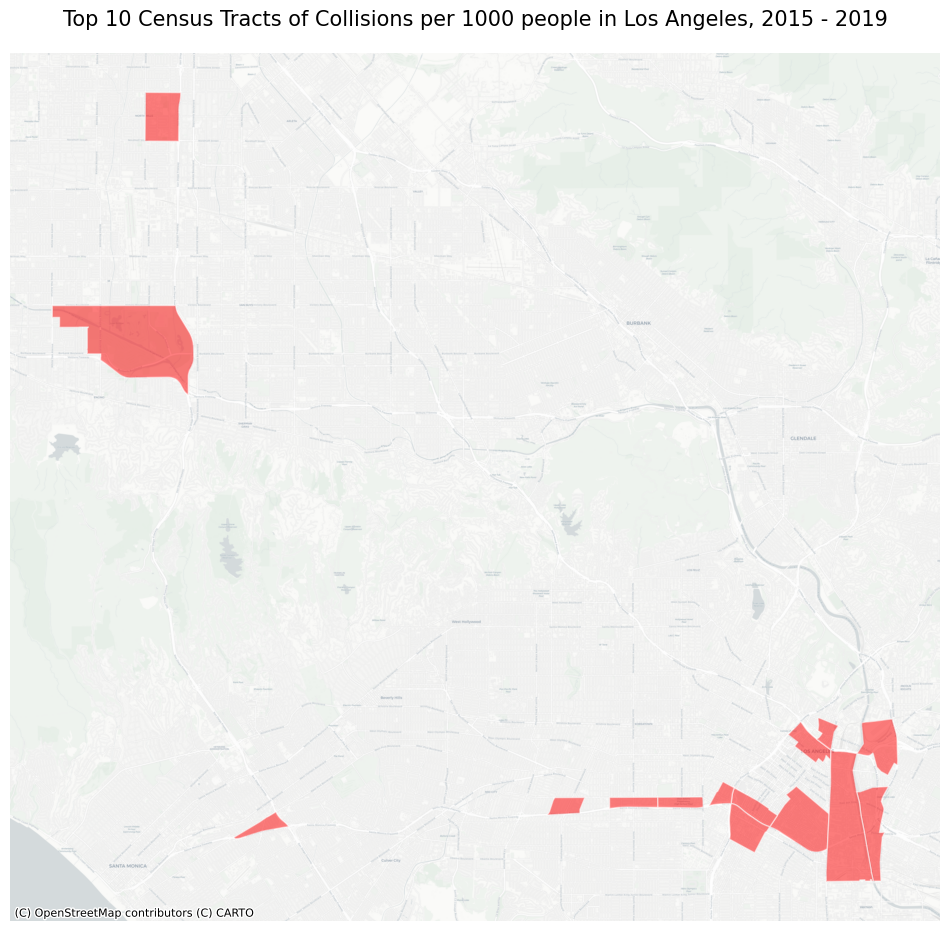

In [52]:
# seeing the location of the top 10 places folks are killed 
fig,ax = plt.subplots(figsize=(12,12))
la_city.sort_values(by='collision_per_1000',ascending=False)[:15].plot(ax=ax,
                                                                 color='red',
                                                                 edgecolor='white',
                                                                 alpha=0.5)


# title
ax.set_title('Top 10 Census Tracts of Collisions per 1000 people in Los Angeles, 2015 - 2019',fontsize=15,pad=20)

# no axis
ax.axis('off')

# add a basemap
ctx.add_basemap(ax, zoom=14, source=ctx.providers.CartoDB.Positron)

<Axes: ylabel='Frequency'>

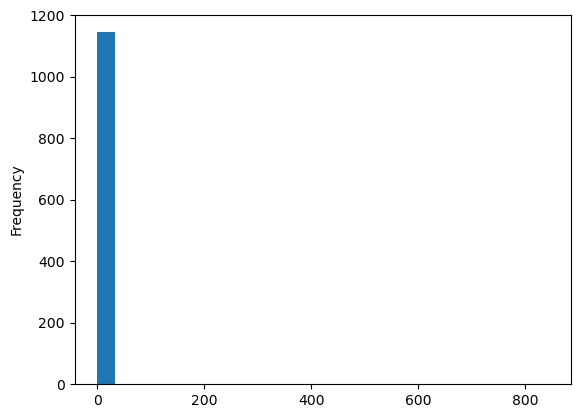

In [53]:
# identifying skew to determine mapping approach
la_city['collision_per_1000'].plot.hist(bins=25)

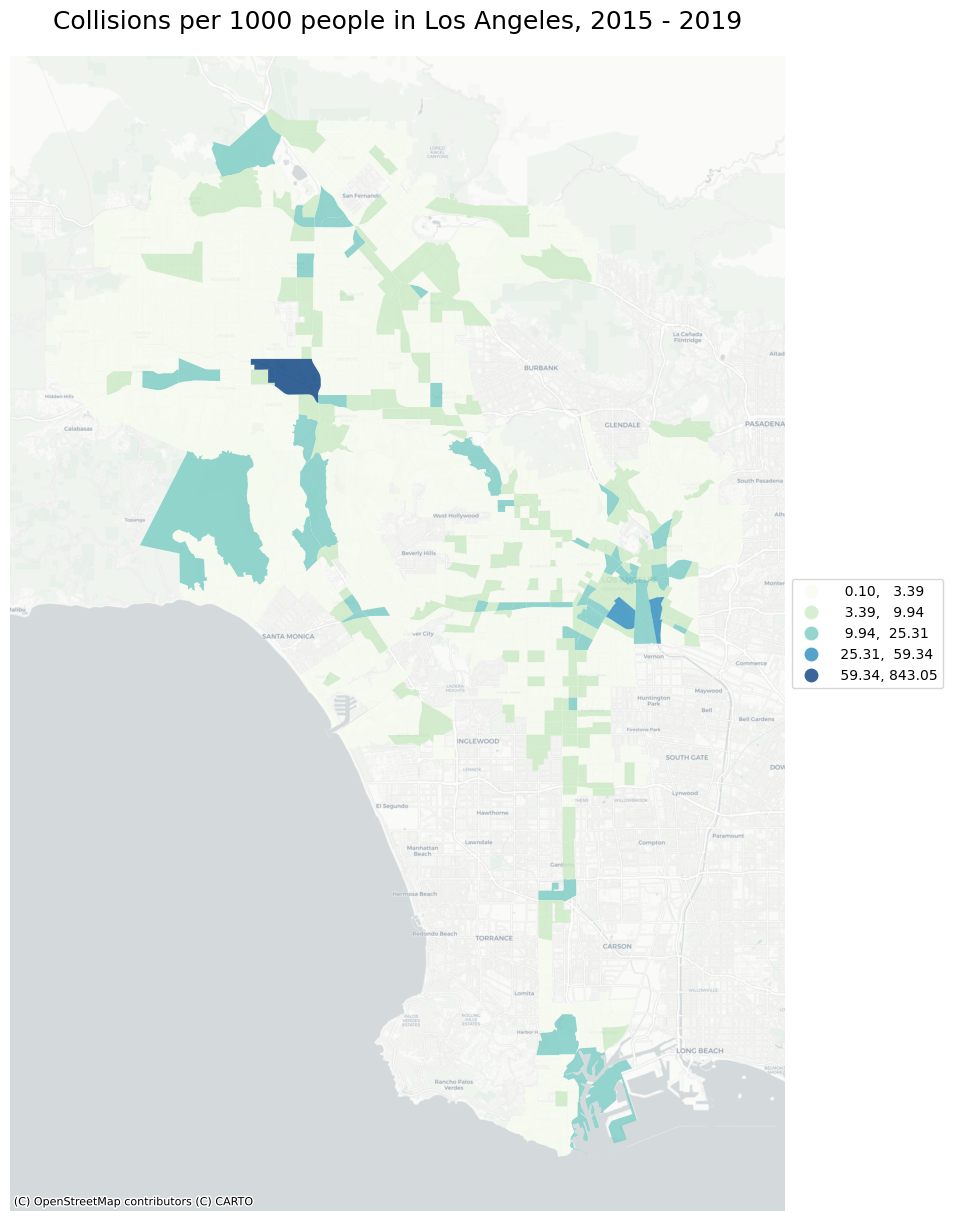

In [55]:
# using natural breaks for choropleth map 
fig,ax = plt.subplots(figsize=(15,15))

la_city.plot(ax=ax,  
        column='collision_per_1000',
        legend=True,
        alpha=0.8,    
        cmap='GnBu', 
        scheme='naturalbreaks',
        legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5)})

ax.axis('off')
ax.set_title('Collisions per 1000 people in Los Angeles, 2015 - 2019',fontsize=18,pad=20)
ctx.add_basemap(ax, zoom= 12,source=ctx.providers.CartoDB.Positron)

In [56]:
# creating interactive map of the same data presented above
la_city.explore(column='collision_per_1000', 
        legend=True,
        cmap='GnBu', 
        scheme='naturalbreaks',
        tiles='CartoDB positron',
        style_kwds={
            'weight':0.5,
            'color':'black',
            'opacity':0.5
        })

In [61]:
# calculating spatial weight 
wq =  lps.weights.KNN.from_dataframe(la_city,k=8)

In [62]:
# row standardization
wq.transform = 'r'

In [63]:
# spatial lag
la_city['collision_per_1000_lag']=lps.weights.lag_spatial(wq, la_city['collision_per_1000'])

In [64]:
# checking data
la_city.head(10)

,FIPS,Total Population,geometry,Total Collision Count,collision_per_1000,collision_per_1000_lag
0,06037101110,4283,"POLYGON ((-13168864.246 4064201.311, -13168757...",3,0.700444,1.276687
1,06037101122,3405,"POLYGON ((-13166582.527 4063754.258, -13166586...",1,0.293686,1.327532
2,06037101210,6347,"POLYGON ((-13167528.967 4063214.44, -13167528....",3,0.472664,1.305160
3,06037101220,3702,"POLYGON ((-13167423.881 4063213.632, -13167369...",1,0.270124,1.242697
4,06037101300,3884,"POLYGON ((-13165229.103 4062741.029, -13165229...",7,1.802266,0.966983
5,06037101400,3458,"POLYGON ((-13169034.788 4063225.626, -13168864...",19,5.494505,0.646829
6,06037102103,1763,"POLYGON ((-13173921.826 4059171.99, -13173936....",4,2.268860,3.261620
7,06037102104,3721,"POLYGON ((-13173332.61 4058687.307, -13173367....",2,0.537490,2.645902
8,06037102105,1905,"POLYGON ((-13173883.427 4056571.41, -13173900....",13,6.824147,1.491933
9,06037102107,4349,"POLYGON ((-13172435.269 4063723.845, -13172429...",6,1.379628,2.368863


In [65]:
# calculating the difference between between killed_per_1000 and the spatial lag ; and sorting the data
la_city['collision_lag_diff'] = la_city['collision_per_1000'] - la_city['collision_per_1000_lag']
la_city.sort_values(by='collision_lag_diff')

,FIPS,Total Population,geometry,Total Collision Count,collision_per_1000,collision_per_1000_lag,collision_lag_diff
224,06037127605,4329,"POLYGON ((-13189783.028 4054868.219, -13189540...",1,0.231000,107.447500,-107.216500
325,06037139701,5320,"POLYGON ((-13189536.919 4051003.355, -13189537...",10,1.879699,108.937818,-107.058118
261,06037132101,4645,"POLYGON ((-13190512.062 4054867.417, -13190374...",1,0.215285,107.232438,-107.017152
324,06037139600,5060,"POLYGON ((-13191481.566 4051699.359, -13191481...",8,1.581028,107.494650,-105.913622
546,06037207900,7162,"POLYGON ((-13164323.023 4034580.051, -13164263...",41,5.724658,17.700282,-11.975624
...,...,...,...,...,...,...,...
116,06037117202,2633,"POLYGON ((-13188263.698 4062429.906, -13188265...",54,20.508925,2.008526,18.500399
888,06037271200,2770,"POLYGON ((-13184392.975 4033478.395, -13184376...",68,24.548736,5.819732,18.729004
534,06037206050,2031,"POLYGON ((-13160021.752 4034590.969, -13159918...",90,44.313146,6.083679,38.229468
702,06037226002,1820,"POLYGON ((-13162261.931 4033499.971, -13162283...",108,59.340659,5.596048,53.744612


In [66]:
# FIPS with the highest negative difference ; look at areas and try to identify potential factors
la_city_donut = la_city.sort_values(by='collision_lag_diff').head(1)
la_city_donut

,FIPS,Total Population,geometry,Total Collision Count,collision_per_1000,collision_per_1000_lag,collision_lag_diff
224,06037127605,4329,"POLYGON ((-13189783.028 4054868.219, -13189540...",1,0.231,107.4475,-107.2165


In [67]:
# FIPS with the highest positive difference 
la_city_diamond = la_city.sort_values(by='collision_lag_diff').tail(1)
la_city_diamond

,FIPS,Total Population,geometry,Total Collision Count,collision_per_1000,collision_per_1000_lag,collision_lag_diff
1146,06037980024,223,"POLYGON ((-13192455.041 4053888.365, -13192239...",188,843.049327,2.606904,840.442424


In [68]:
# creating a map using satellite imagery, this image describes the census tract that has a low collision count while surrounding tracts have higher collision counts. 
la_city_donut.explore(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                  attr= 'Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community')

In [69]:
# creating a map using satellite imagery, this image describes the census tract that has a high collision count while surrounding tracts have a lower collision counts. 
la_city_diamond.explore(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                  attr= 'Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community')

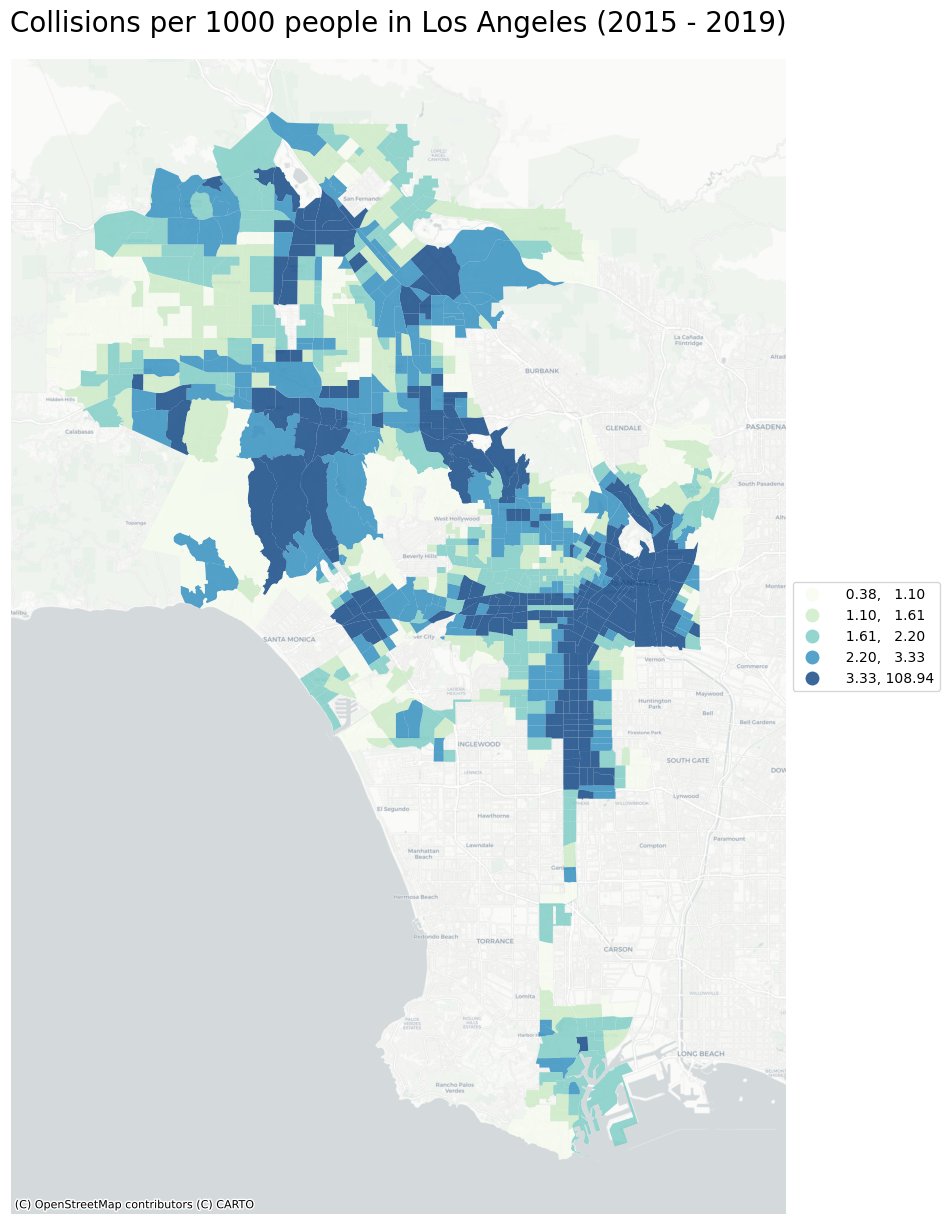

In [70]:
# spatial lag map - mapping the entire dataframe
fig, ax = plt.subplots(figsize=(15, 15))

la_city.plot(ax=ax,
         figsize=(15,15),
         column='collision_per_1000_lag',
         legend=True,
         alpha=0.8,
         cmap='GnBu',
         scheme='quantiles', 
         legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5)})

ax.axis('off')
ax.set_title('Collisions per 1000 people in Los Angeles (2015 - 2019)',fontsize=20,pad=20)

ctx.add_basemap(ax,zoom =12, source=ctx.providers.CartoDB.Positron)

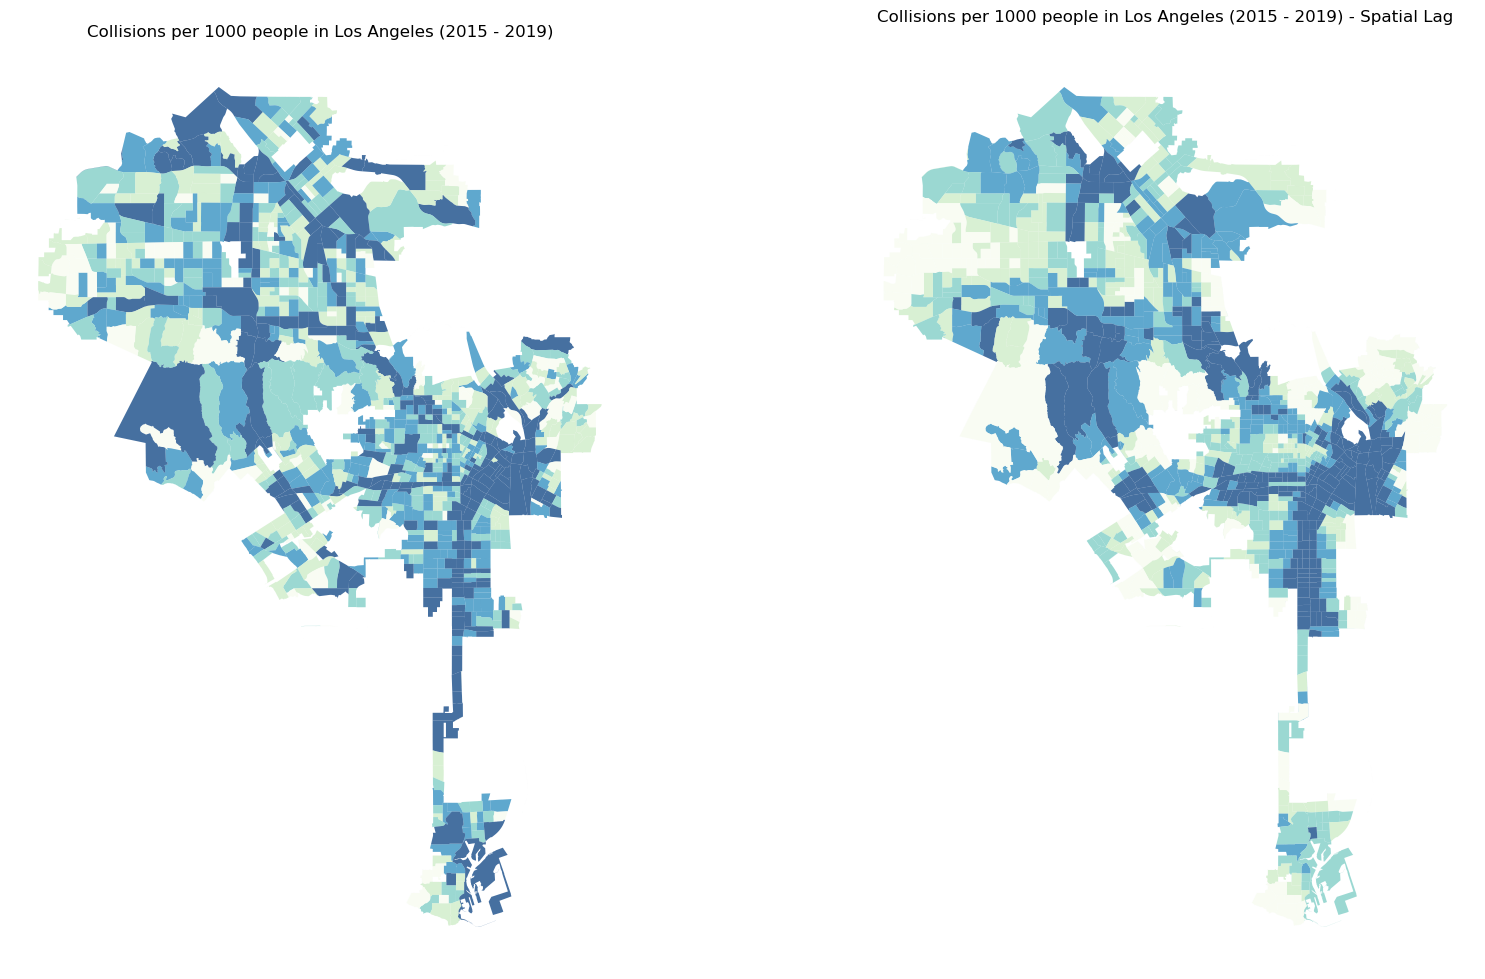

In [71]:
# ploting both collisions per 1000 and lag 
fig, ax = plt.subplots(1, 2, figsize=(20, 12))

#ax[0] - map on the left 
la_city.plot(ax=ax[0], # this assigns the map to the left subplot
         column='collision_per_1000', 
         cmap='GnBu', 
         scheme='quantiles',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75, 
           )


ax[0].axis("off")
ax[0].set_title("Collisions per 1000 people in Los Angeles (2015 - 2019)")

# ax[1] - map on the right 
la_city.plot(ax=ax[1], 
         column='collision_per_1000_lag', 
         cmap='GnBu', 
         scheme='quantiles',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75
           )

ax[1].axis("off")
ax[1].set_title("Collisions per 1000 people in Los Angeles (2015 - 2019) - Spatial Lag")

plt.show()

In [72]:
# quantifying the degree of spatial correlation, output was positive meaning that high collision tracts are located near other high collision tracts and vise versa
y = la_city.collision_per_1000
moran = Moran(y, wq)
moran.I

np.float64(0.0033051760580260253)

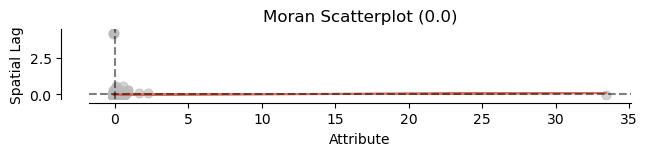

In [73]:
# creating scatterplot
fig, ax = moran_scatterplot(moran, aspect_equal=True)
plt.show()

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.0', ylabel='Density'>)

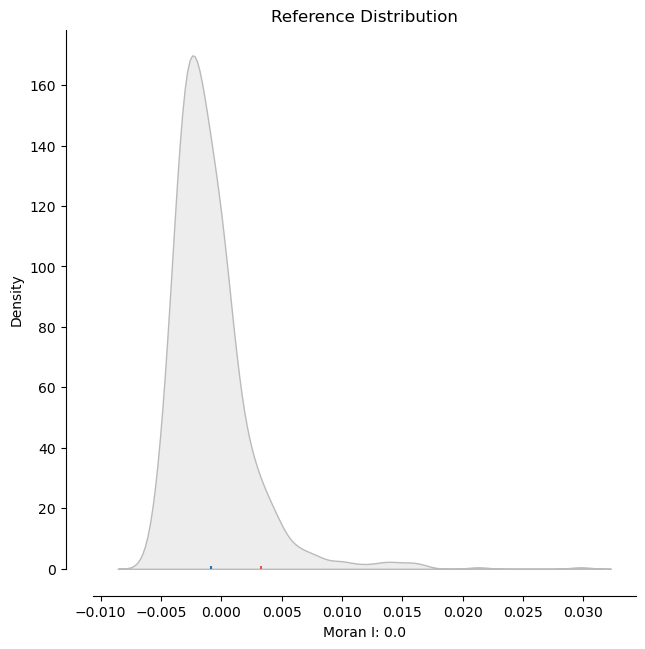

In [74]:
# dcreating reference distribution
plot_moran_simulation(moran,aspect_equal=False)

In [75]:
# p-value , 99% confidence, we are 99% confient that there is statistically significantly spatial clustering with collisions per 1,000 residents in the City of LA from 2015-2019. 
moran.p_sim

np.float64(0.077)

In [76]:
# moran local scatterplot
lisa = esda.moran.Moran_Local(y, wq)

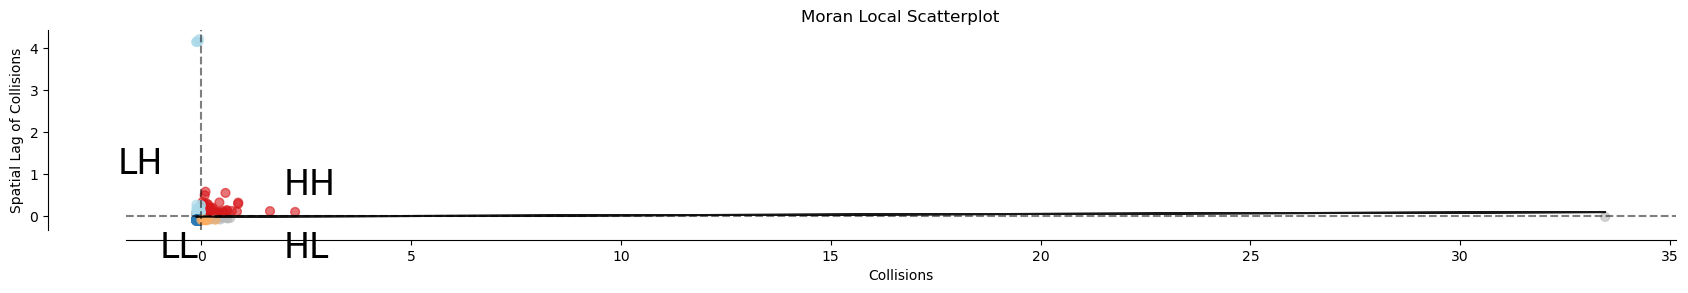

In [77]:
# plot 
fig,ax = plt.subplots(figsize=(20,15))

moran_scatterplot(lisa, ax=ax, p=0.05)
ax.set_xlabel("Collisions")
ax.set_ylabel('Spatial Lag of Collisions')

# test #1 
# nedd to play with the number more?
plt.text(1.95, 0.5, "HH", fontsize=25) 
plt.text(1.95, -1, "HL", fontsize=25)
plt.text(-2, 1, "LH", fontsize=25)
plt.text(-1, -1, "LL", fontsize=25)
plt.show()

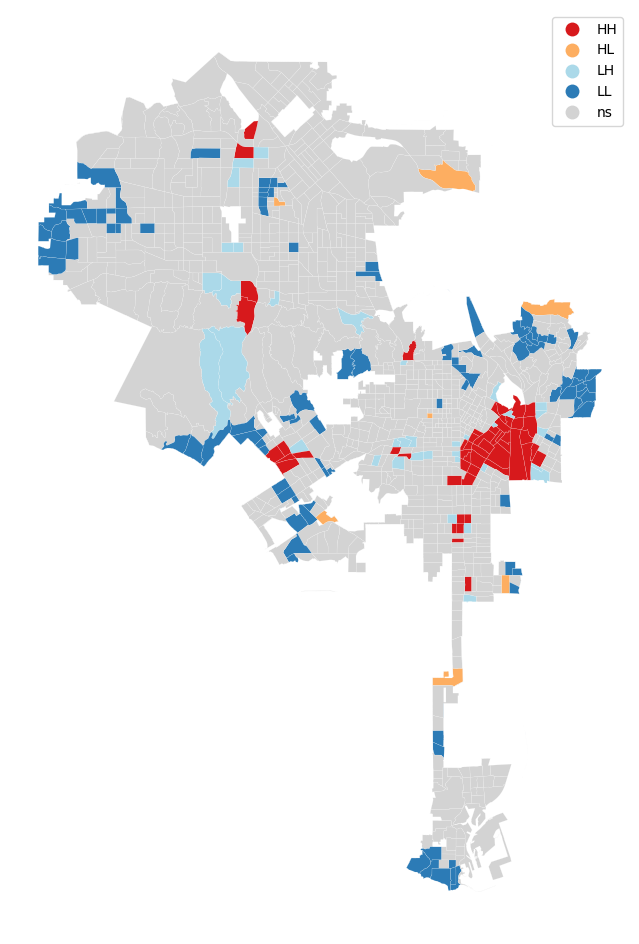

In [78]:
# mapping 
fig, ax = plt.subplots(figsize=(14,12))
lisa_cluster(lisa, la_city, p=0.05, ax=ax) 
plt.show()

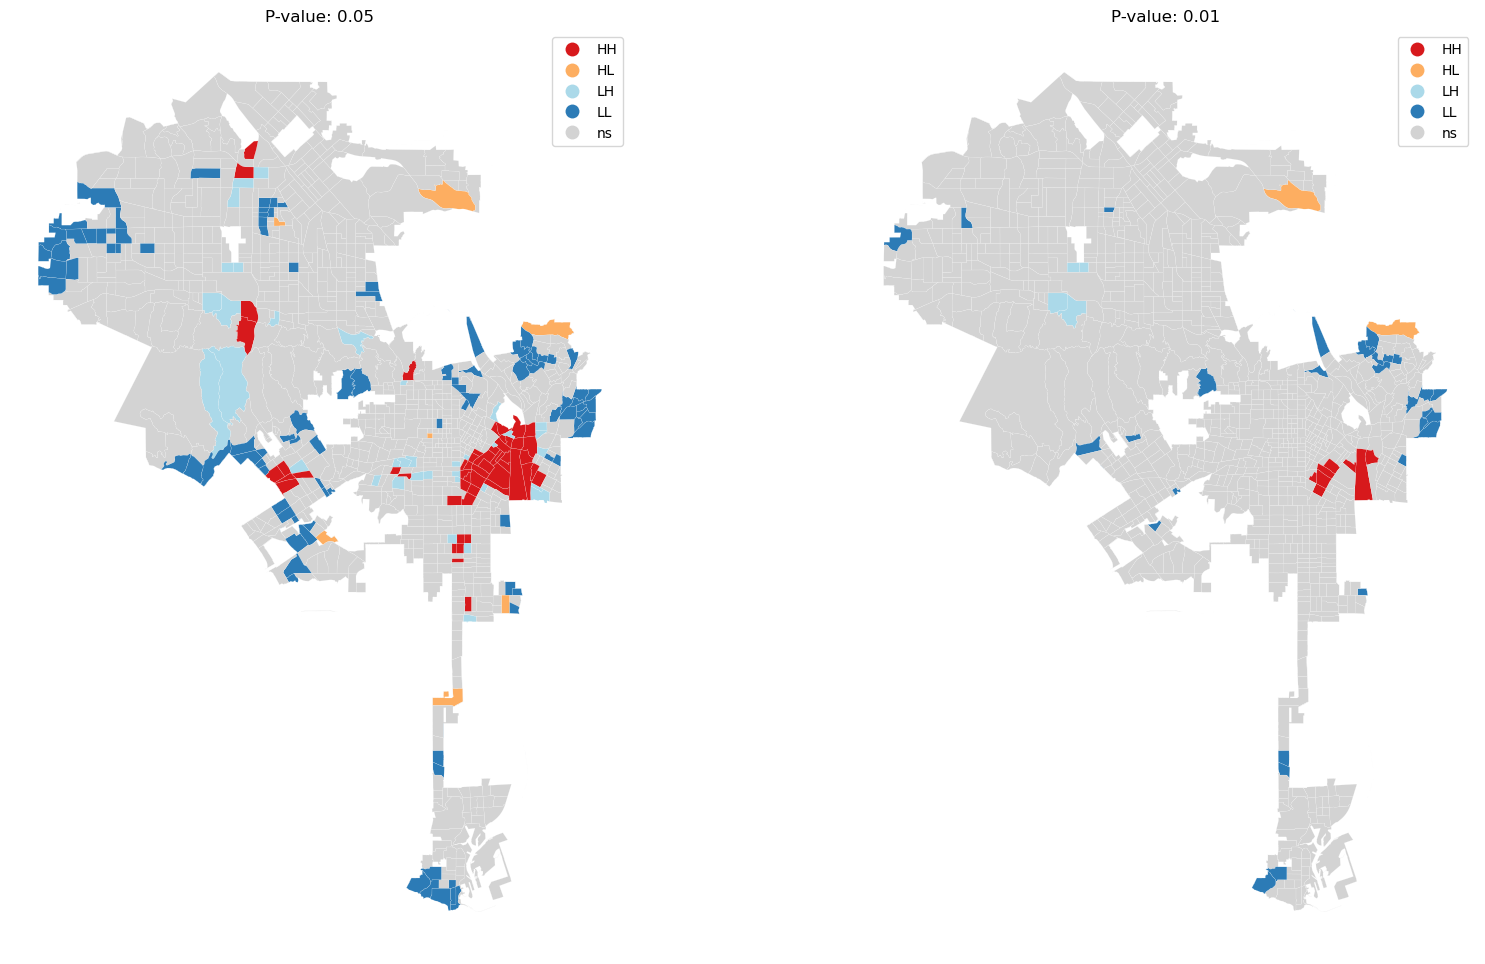

In [79]:
# create maps with different p-values
# create the 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 12))

# regular count map on the left
lisa_cluster(lisa,la_city, p=0.05, ax=ax[0])

ax[0].axis("off")
ax[0].set_title("P-value: 0.05")

# spatial lag map on the right
lisa_cluster(lisa, la_city, p=0.01, ax=ax[1])
ax[1].axis("off")
ax[1].set_title("P-value: 0.01")

plt.show()

## Team Roles

### Emily

Conducted spatial analysis for fatal pedestrian and bicycle collisions in the City of LA 

### Gema 

Conducted spatial analysis for pedestrian in the City of LA 

### Veronica 
Conducted spatial analysis for fatal bicycle collisions in the City of LA 